[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_10/SFM_ch10_seminar/SFM_ch10_seminar.ipynb)

# Statistics of Financial Markets — Seminar 10: VaR, ES and backtesting

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 10: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch10_seminar`: student version of the Seminar 10 notebook. Solved exercises (A1, A3, A5, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Returns; VaR and ES by historical simulation, Normal, Student-t, Cornish–Fisher and EVT; GARCH(1,1)-t; the Kupiec and Christoffersen tests and the Basel zones; portfolio data, pseudo-observations and copulas.
- Helpers for Part A and Part B: a Normal or Student-t position, the worst returns of a series, two bonds, the Kupiec test with the traffic light, the Christoffersen test from transition counts, five methods, a yearly backtest, a two-asset portfolio.

In [ ]:
from arch import arch_model
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'tlv', 'snp']
BT_ASSETS = ['sp500', 'dax', 'bet', 'btc']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
EPISODES = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-15', '2020-05-31')}
ALPHA_VAR = 0.01
ALPHA_ES = 0.025
WINDOW = 500
REFIT = 250
OOS_START = {'sp500': '2005-01-01', 'dax': '2005-01-01', 'bet': '2005-01-01', 'btc': '2017-01-01'}
POT_Q = 0.9
METHODS = ['HS', 'Normal', 'GARCH-t', 'FHS']
MCOL = {'HS': '#B5853F', 'Normal': '#2E7D32', 'GARCH-t': '#CD0000', 'FHS': '#1A3A6E'}
PORT = ('bet', 'sp500')
WEIGHTS = (0.5, 0.5)
N_SIM = 200000
N_Z2 = 1000
SEED = 2026
PLUS = {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.4, 6: 0.5, 7: 0.65, 8: 0.75, 9: 0.85}


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def hs_var(x, a=ALPHA_VAR):
    """Historical simulation: VaR_a = -r_(k), the k-th smallest return, k = ceil(n a)."""
    xs = np.sort(np.asarray(x, float))
    k = int(np.ceil(len(xs) * a - 1e-9))
    return float(-xs[k - 1])


def hs_es(x, a=ALPHA_ES):
    """Historical simulation: ES_a = minus the average of the k smallest returns, k = ceil(n a)."""
    xs = np.sort(np.asarray(x, float))
    k = int(np.ceil(len(xs) * a - 1e-9))
    return float(-xs[:k].mean())


def normal_var(mu, sd, a=ALPHA_VAR):
    """VaR_a = -(mu + sd z_a), z_a the a-quantile of N(0, 1) (negative)."""
    return float(-(mu + sd * stats.norm.ppf(a)))


def normal_es(mu, sd, a=ALPHA_ES):
    """ES_a = -mu + sd phi(z_a) / a."""
    return float(-mu + sd * stats.norm.pdf(stats.norm.ppf(a)) / a)


def t_es_factor(nu, a=ALPHA_ES):
    """ES of a Student-t variable with nu degrees of freedom (scale 1): f(t_a) (nu + t_a^2) / ((nu - 1) a)."""
    q = stats.t.ppf(a, nu)
    return float(stats.t.pdf(q, nu) * (nu + q ** 2) / ((nu - 1) * a))


def std_t_q(nu, a=ALPHA_VAR):
    """a-quantile of the standardised Student-t (variance 1): t_nu^{-1}(a) sqrt((nu - 2)/nu)."""
    return float(stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu))


def std_t_es(nu, a=ALPHA_ES):
    """ES_a of the standardised Student-t (variance 1)."""
    return float(np.sqrt((nu - 2) / nu) * t_es_factor(nu, a))


def t_fit(x):
    """Student-t with location m, scale s and nu degrees of freedom, fitted by maximum likelihood (scipy)."""
    nu, m, s = stats.t.fit(np.asarray(x, float))
    return float(nu), float(m), float(s)


def t_var_es(x, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    nu, m, s = t_fit(x)
    return {'var': float(-(m + s * stats.t.ppf(a_var, nu))), 'es': float(-m + s * t_es_factor(nu, a_es)),
            'nu': nu, 'm': m, 's': s}


def cf_z(a, S, K):
    """Cornish-Fisher quantile of a standardised variable with skewness S and excess kurtosis K."""
    z = stats.norm.ppf(a)
    return z + (z ** 2 - 1) * S / 6 + (z ** 3 - 3 * z) * K / 24 - (2 * z ** 3 - 5 * z) * S ** 2 / 36


def cf_var_es(x, a_var=ALPHA_VAR, a_es=ALPHA_ES):
    """Cornish-Fisher VaR = -(mu + sd z_cf); ES = minus the average of the CF quantiles on (0, a_es)."""
    x = np.asarray(x, float)
    mu, sd = x.mean(), x.std(ddof=1)
    S, K = float(stats.skew(x)), float(stats.kurtosis(x))
    u = (np.arange(2000) + 0.5) / 2000 * a_es
    return {'var': float(-(mu + sd * cf_z(a_var, S, K))), 'es': float(-(mu + sd * cf_z(u, S, K).mean())),
            'z': float(cf_z(a_var, S, K)), 'S': S, 'K': K, 'mu': float(mu), 'sd': float(sd)}


def pot_fit(x, q=POT_Q):
    """GPD fit to the losses L = -r above the threshold u = q-quantile of the losses (peaks over threshold)."""
    L = -np.asarray(x, float)
    u = float(np.quantile(L, q))
    exc = L[L > u] - u
    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    return {'u': u, 'xi': float(xi), 'beta': float(beta), 'Nu': int(len(exc)), 'n': int(len(L))}


def pot_var(f, a):
    """VaR_a = u + beta/xi [(n a / N_u)^(-xi) - 1], valid for a < N_u / n."""
    return float(f['u'] + f['beta'] / f['xi'] * ((f['n'] * a / f['Nu']) ** (-f['xi']) - 1))


def pot_es(f, a):
    """ES_a = VaR_a / (1 - xi) + (beta - xi u) / (1 - xi), valid for xi < 1."""
    return float(pot_var(f, a) / (1 - f['xi']) + (f['beta'] - f['xi'] * f['u']) / (1 - f['xi']))


def garch_fit(r, last_obs=None):
    """GARCH(1,1) with constant mean and standardised Student-t innovations (arch package)."""
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    return am.fit(disp='off', last_obs=last_obs, options={'maxiter': 2000})


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec (1995) proportion-of-failures test: LR_uc = -2 ln[(1-a)^(n-x) a^x / ((1-x/n)^(n-x) (x/n)^x)] ~ chi2(1)."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = (n - x) * np.log(1 - ph) if ph < 1 else 0.0
    l1 += x * np.log(ph) if x > 0 else 0.0
    lr = float(-2 * (l0 - l1))
    return {'x': int(x), 'n': int(n), 'rate': float(ph), 'lr': lr, 'p': float(stats.chi2.sf(lr, 1))}


def christoffersen(hits, a=ALPHA_VAR):
    """Christoffersen (1998): independence LR_ind ~ chi2(1) from the transition counts n_ij (i = yesterday,
    j = today), and conditional coverage LR_cc = LR_uc + LR_ind ~ chi2(2)."""
    h = np.asarray(hits, int)
    h0, h1 = h[:-1], h[1:]
    n00 = int(np.sum((h0 == 0) & (h1 == 0)))
    n01 = int(np.sum((h0 == 0) & (h1 == 1)))
    n10 = int(np.sum((h0 == 1) & (h1 == 0)))
    n11 = int(np.sum((h0 == 1) & (h1 == 1)))
    p01 = n01 / (n00 + n01) if n00 + n01 else 0.0
    p11 = n11 / (n10 + n11) if n10 + n11 else 0.0
    p = (n01 + n11) / (n00 + n01 + n10 + n11)

    def ll(q, a_, b_):
        return (a_ * np.log(1 - q) if a_ and q < 1 else 0.0) + (b_ * np.log(q) if b_ and q > 0 else 0.0)
    lr_ind = float(-2 * (ll(p, n00 + n10, n01 + n11) - ll(p01, n00, n01) - ll(p11, n10, n11)))
    uc = kupiec(int(h.sum()), len(h), a)
    lr_cc = uc['lr'] + lr_ind
    return {'n00': n00, 'n01': n01, 'n10': n10, 'n11': n11, 'p01': float(p01), 'p11': float(p11),
            'lr_ind': lr_ind, 'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'lr_cc': float(lr_cc),
            'p_cc': float(stats.chi2.sf(lr_cc, 2)), 'uc': uc}


def basel_zone(x):
    """Basel traffic light for 250 days at VaR 1%: green 0-4, yellow 5-9, red 10 or more exceptions."""
    return 'green' if x <= 4 else ('yellow' if x <= 9 else 'red')


def portfolio_data(keys=PORT):
    """Prices joined on common days first, then simple returns in % (the portfolio return is linear in them)."""
    P = pd.concat([load_close(k, START.get(k)) for k in keys], axis=1).dropna()
    R = 100 * P.pct_change().dropna()
    R.columns = list(keys)
    return R


def pseudo_obs(R):
    """Ranks divided by n + 1: the empirical copula sample (uniform margins)."""
    return R.rank().values / (len(R) + 1)


def t_copula_loglik(U, rho, nu):
    """Log-likelihood of the bivariate t copula with correlation rho and nu degrees of freedom."""
    x = stats.t.ppf(U, nu)
    q = (x[:, 0] ** 2 - 2 * rho * x[:, 0] * x[:, 1] + x[:, 1] ** 2) / (1 - rho ** 2)
    from scipy.special import gammaln
    lj = (gammaln((nu + 2) / 2) - gammaln(nu / 2) - np.log(nu * np.pi) - 0.5 * np.log(1 - rho ** 2)
          - (nu + 2) / 2 * np.log1p(q / nu))
    return float(np.sum(lj - stats.t.logpdf(x[:, 0], nu) - stats.t.logpdf(x[:, 1], nu)))


def gauss_copula_loglik(U, rho):
    x = stats.norm.ppf(U)
    q = (rho ** 2 * (x[:, 0] ** 2 + x[:, 1] ** 2) - 2 * rho * x[:, 0] * x[:, 1]) / (1 - rho ** 2)
    return float(np.sum(-0.5 * np.log(1 - rho ** 2) - 0.5 * q))


def t_tail_dependence(rho, nu):
    """lambda = 2 t_{nu+1}(-sqrt((nu + 1)(1 - rho)/(1 + rho))); the Gaussian copula has lambda = 0."""
    return float(2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1))


def copula_fit(R):
    """rho from Kendall's tau (rho = sin(pi tau / 2)); nu of the t copula by maximum likelihood over a grid."""
    U = pseudo_obs(R)
    tau = float(stats.kendalltau(R.iloc[:, 0], R.iloc[:, 1])[0])
    rho = float(np.sin(np.pi * tau / 2))
    grid = np.arange(2.0, 40.01, 0.25)
    ll = np.array([t_copula_loglik(U, rho, v) for v in grid])
    nu = float(grid[np.argmax(ll)])
    return {'tau': tau, 'rho': rho, 'nu': nu, 'll_t': float(ll.max()), 'll_g': gauss_copula_loglik(U, rho),
            'lambda_t': t_tail_dependence(rho, nu), 'pearson': float(R.corr().iloc[0, 1]),
            'spearman': float(stats.spearmanr(R.iloc[:, 0], R.iloc[:, 1])[0])}


def empirical_tail_dep(R, qs=(0.05, 0.01)):
    """P(U1 <= q | U2 <= q): the share of the worst q of days of asset 2 that are also among the worst q of asset 1;
    under independence it equals q."""
    U = pseudo_obs(R)
    return {f'{q:g}': float(np.mean((U[:, 0] <= q) & (U[:, 1] <= q)) / q) for q in qs}


def simulate_copula(rho, nu=None, n=N_SIM, seed=SEED):
    """Uniform pairs from the Gaussian copula (nu None) or the t copula with correlation rho."""
    rng = np.random.default_rng(seed)
    Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    if nu is None:
        return stats.norm.cdf(Z)
    w = np.sqrt(nu / rng.chisquare(nu, n))
    return stats.t.cdf(Z * w[:, None], nu)


def normal_position(V, mu, sd, h=10):
    """Normal VaR 1% and ES 2.5% of a position of value V (daily returns in %), in % and in currency; h-day VaR by the
    square-root-of-time rule (mean ignored)."""
    z1, z25 = stats.norm.ppf(ALPHA_VAR), stats.norm.ppf(ALPHA_ES)
    v1, e25 = normal_var(mu, sd), normal_es(mu, sd)
    return {'z1': float(z1), 'z25': float(z25), 'phi25': float(stats.norm.pdf(z25)), 'var1': v1, 'es25': e25,
            'var1_cur': V * v1 / 100, 'es25_cur': V * e25 / 100, 'var_h': float(np.sqrt(h) * (-z1) * sd),
            'var_h_cur': V * float(np.sqrt(h) * (-z1) * sd) / 100, 'ratio': e25 / v1}


def t_position(V, mu, sd, nu):
    """Standardised Student-t innovations: VaR 1% = -(mu + sd q), ES 2.5% = -mu + sd ES_z."""
    t1, t25 = stats.t.ppf(ALPHA_VAR, nu), stats.t.ppf(ALPHA_ES, nu)
    sc = np.sqrt((nu - 2) / nu)
    q = std_t_q(nu, ALPHA_VAR)
    ez = std_t_es(nu, ALPHA_ES)
    v1, e25 = -(mu + sd * q), -mu + sd * ez
    return {'t1': float(t1), 't25': float(t25), 'f25': float(stats.t.pdf(t25, nu)), 'sc': float(sc), 'q': q,
            'fac': t_es_factor(nu, ALPHA_ES), 'ez': ez, 'var1': float(v1), 'es25': float(e25),
            'var1_cur': V * v1 / 100, 'es25_cur': V * e25 / 100, 'ratio': float(e25 / v1)}


def worst_returns(k='bet', n=500, m=15):
    """The m smallest of the last n daily returns, with their dates, and the historical VaR 1% and ES 2.5%."""
    r = returns(k).iloc[-n:]
    w = r.sort_values().iloc[:m]
    return {'n': n, 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
            'worst': [float(round(v, 2)) for v in w.values], 'dates': [d.date().isoformat() for d in w.index],
            'k1': int(np.ceil(n * ALPHA_VAR)), 'k25': int(np.ceil(n * ALPHA_ES)),
            'var1': float(-round(w.values[int(np.ceil(n * ALPHA_VAR)) - 1], 2)),
            'es25': float(-np.mean(np.round(w.values[:int(np.ceil(n * ALPHA_ES))], 2)))}


def two_bonds(p, loss=100.0, a=0.05):
    """Two independent bonds, each losing `loss` with probability p: VaR and ES at level a of each and of the sum."""
    def var_es(vals, probs):
        order = np.argsort(vals)[::-1]                     # losses from the largest
        v, pr = np.asarray(vals)[order], np.asarray(probs)[order]
        cum = np.cumsum(pr)
        var = float(v[np.argmax(cum > a)])                 # smallest loss l with P(L > l) <= a
        rest, es = a, 0.0
        for vi, pi in zip(v, pr):
            take = min(pi, rest)
            es += take * vi
            rest -= take
            if rest <= 1e-15:
                break
        return var, es / a
    v1, e1 = var_es([0, loss], [1 - p, p])
    v2, e2 = var_es([0, loss, 2 * loss], [(1 - p) ** 2, 2 * p * (1 - p), p ** 2])
    return {'p': p, 'a': a, 'p_any': 1 - (1 - p) ** 2, 'p_both': p ** 2, 'p_one': 2 * p * (1 - p),
            'var1': v1, 'es1': e1, 'var2': v2, 'es2': e2}


def kupiec_traffic(x, n=250):
    """Kupiec test and Basel zone for x exceptions of VaR 1% in n days."""
    k = kupiec(x, n)
    ph = x / n
    return dict(k, l0=float((n - x) * np.log(0.99) + x * np.log(0.01)),
                l1=float((n - x) * np.log(1 - ph) + x * np.log(ph)), zone=basel_zone(x) if n == 250 else None,
                plus=PLUS.get(x, 1.0), cum=float(stats.binom.cdf(x, n, ALPHA_VAR)),
                cum_prev=float(stats.binom.cdf(x - 1, n, ALPHA_VAR)))


def christoffersen_counts(n00, n01, n10, n11):
    """Christoffersen test from given transition counts n_ij (i = yesterday, j = today)."""
    p01, p11 = n01 / (n00 + n01), n11 / (n10 + n11)
    p = (n01 + n11) / (n00 + n01 + n10 + n11)
    ll0 = (n00 + n10) * np.log(1 - p) + (n01 + n11) * np.log(p)
    ll1 = n00 * np.log(1 - p01) + n01 * np.log(p01) + n10 * np.log(1 - p11) + (n11 * np.log(p11) if n11 else 0)
    lr_ind = float(-2 * (ll0 - ll1))
    x, n = n01 + n11, n00 + n01 + n10 + n11
    uc = kupiec(x, n)
    return {'p01': p01, 'p11': p11, 'p': p, 'll0': float(ll0), 'll1': float(ll1), 'lr_ind': lr_ind,
            'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'lr_uc': uc['lr'], 'p_uc': uc['p'], 'lr_cc': uc['lr'] + lr_ind,
            'p_cc': float(stats.chi2.sf(uc['lr'] + lr_ind, 2)), 'x': x, 'n': n}


def five_methods(k):
    """VaR 1% and ES 2.5% (in %) by historical simulation, Normal, Student-t, Cornish-Fisher and EVT (POT)."""
    x = returns(k)
    mu, sd = float(x.mean()), float(x.std())
    tt = t_var_es(x)
    cf = cf_var_es(x)
    f = pot_fit(x)
    return {'n': int(len(x)), 'first': x.index[0].date().isoformat(), 'mu': mu, 'sd': sd, 'skew': cf['S'],
            'exkurt': cf['K'], 'nu': tt['nu'], 'xi': f['xi'], 'u': f['u'], 'Nu': f['Nu'], 'beta': f['beta'],
            'cf_z': cf['z'],
            'HS': (hs_var(x), hs_es(x)), 'Normal': (normal_var(mu, sd), normal_es(mu, sd)),
            'Student-t': (tt['var'], tt['es']), 'Cornish-Fisher': (cf['var'], cf['es']),
            'EVT': (pot_var(f, ALPHA_VAR), pot_es(f, ALPHA_ES))}


def yearly_backtest(k, start='2015-01-01', window=250):
    """Historical simulation on the last `window` days and GARCH(1,1)-t re-estimated at the start of every calendar
    year (data up to the previous day): VaR 1% exceptions per calendar year, Kupiec and Christoffersen on the whole
    period, Basel zone of each year."""
    r = returns(k)
    years = sorted(set(r.loc[start:].index.year))
    out = {'years': {}, 'hits': {'HS': [], 'GARCH-t': []}}
    for y in years:
        idx = r.loc[str(y)].index
        s0 = r.index.get_loc(idx[0])
        e0 = r.index.get_loc(idx[-1]) + 1
        hs = np.array([hs_var(r.values[t - window:t]) for t in range(s0, e0)])
        res = garch_fit(r.iloc[:e0], last_obs=idx[0])
        from arch import arch_model
        am = arch_model(r.iloc[:e0], mean='Constant', vol='GARCH', p=1, q=1, dist='t')
        sig = am.fix(res.params).conditional_volatility.iloc[s0:e0].values
        p = res.params
        g = -(p['mu'] + sig * std_t_q(p['nu']))
        rr = r.values[s0:e0]
        hh, hg = (rr < -hs).astype(int), (rr < -g).astype(int)
        out['hits']['HS'] += list(hh)
        out['hits']['GARCH-t'] += list(hg)
        out['years'][str(y)] = {'n': int(len(rr)), 'HS': int(hh.sum()), 'GARCH-t': int(hg.sum()),
                                'zone_HS': basel_zone(hh.sum()), 'zone_G': basel_zone(hg.sum())}
    for m in ('HS', 'GARCH-t'):
        h = np.array(out['hits'][m])
        c = christoffersen(h)
        out[m] = {'n': int(len(h)), 'x': int(h.sum()), 'rate': float(h.mean()), 'lr_uc': c['uc']['lr'], 'p_uc': c['uc']['p'],
                  'lr_ind': c['lr_ind'], 'p_ind': c['p_ind'], 'lr_cc': c['lr_cc'], 'p_cc': c['p_cc'], 'n11': c['n11'],
                  'red': int(sum(1 for v in out['years'].values() if (v['zone_HS'] if m == 'HS' else v['zone_G']) == 'red')),
                  'yellow': int(sum(1 for v in out['years'].values() if (v['zone_HS'] if m == 'HS' else v['zone_G']) == 'yellow'))}
    del out['hits']
    return out


def two_asset_portfolio(keys, w=(0.5, 0.5)):
    """Variance-covariance and historical VaR 1% / ES 2.5% of a 50/50 portfolio (simple returns in %, common days);
    correlations in 2017 and in February-May 2020; tail dependence; Gaussian and t copula simulations."""
    P = pd.concat([load_close(k, START.get(k)) for k in keys], axis=1).dropna()
    R = 100 * P.pct_change().dropna()
    R.columns = list(keys)
    w = np.asarray(w)
    mu, S = R.mean().values, R.cov().values
    sd = np.sqrt(np.diag(S))
    sp = float(np.sqrt(w @ S @ w))
    mp = float(w @ mu)
    rp = R.values @ w
    cf = copula_fit(R)
    out = {'n': int(len(R)), 'first': R.index[0].date().isoformat(), 'mu': mu.tolist(), 'sd': sd.tolist(),
           'corr': float(R.corr().iloc[0, 1]), 'sp': sp, 'mp': mp, 'var_n': normal_var(mp, sp), 'es_n': normal_es(mp, sp),
           'var_single': [normal_var(mu[i], sd[i]) for i in range(2)],
           'var_hs': hs_var(rp), 'es_hs': hs_es(rp), 'var_hs_single': [hs_var(R.values[:, i]) for i in range(2)],
           'corr_2017': float(R.loc['2017'].corr().iloc[0, 1]), 'corr_2020': float(R.loc['2020-02-15':'2020-05-31'].corr().iloc[0, 1]),
           'tail': empirical_tail_dep(R), 'copula': cf}
    out['var_sum'] = float(w @ np.array(out['var_single']))
    out['var_hs_sum'] = float(w @ np.array(out['var_hs_single']))
    out['benefit'] = 1 - out['var_n'] / out['var_sum']
    for lab, nu in [('gauss', None), ('t', cf['nu'])]:
        U = simulate_copula(cf['rho'], nu)
        X = np.column_stack([np.quantile(R.values[:, i], U[:, i]) for i in range(2)])
        out[f'var_{lab}'] = hs_var(X @ w)
        out[f'es_{lab}'] = hs_es(X @ w)
    out['R'] = R
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: VaR and ES of a Normal position

**Context.** A position of 1,000,000 RON; daily returns $N(\mu, \sigma^2)$ with $\mu = 0.05\%$, $\sigma = 1.4\%$.

1. Compute VaR 1% in % and in RON.
2. Compute ES 2.5% in % and in RON.
3. Compute the 10-day VaR 1% with the square-root-of-time rule ($\mu$ ignored).
4. Compute the ratio ES 2.5% / VaR 1%.

**Report:** six numbers and one sentence.

In [8]:
# Solution
normal_position(1_000_000, 0.05, 1.4)

{'z1': -2.3263478740408408,
 'z25': -1.9599639845400545,
 'phi25': 0.058445069805035325,
 'var1': 3.206887023657177,
 'es25': 3.222923909081978,
 'var1_cur': 32068.870236571773,
 'es25_cur': 32229.239090819778,
 'var_h': 10.299181076603375,
 'var_h_cur': 102991.81076603376,
 'ratio': 1.0050007640763448}

**Interpretation of the result.** For Normal returns ES 2.5% and VaR 1% are almost the same number (ratio about 1.005).

## A2 [Proposed]: the same position with Student-t returns

**Context.** As in A1, but the standardised returns are Student-t with $\nu = 4$. Model: A1.

1. Compute $q_{0.01}(z)$ and VaR 1% in % and in RON.
2. Compute $\mathrm{ES}_{2.5\%}(z)$ and ES 2.5% in % and in RON.
3. Compare both numbers with A1.

**Report:** six numbers and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: historical simulation from the worst days of the BET

**Context.** The last 500 daily BET returns and their 15 smallest values.

1. Compute VaR 1% and VaR 2.5% by historical simulation.
2. Compute ES 2.5%.
3. Translate VaR 1% and ES 2.5% into RON for a position of 1,000,000 RON.

**Report:** five numbers and one sentence.

In [10]:
# Solution
w = worst_returns('bet')
print(w['worst'])
{c: w[c] for c in ['k1', 'k25', 'var1', 'es25']}

[-3.68, -3.35, -3.12, -3.03, -2.93, -2.71, -2.61, -2.41, -2.38, -2.33, -2.27, -2.11, -2.08, -2.02, -1.93]


{'k1': 5, 'k25': 13, 'var1': 2.93, 'es25': 2.693076923076923}

**Interpretation of the result.** Here ES 2.5% is below VaR 1%: ES is larger than VaR only at the same level (ES 2.5% is above VaR 2.5%).

## A4 [Proposed]: two bonds and subadditivity

**Context.** Two independent bonds; each loses 100 with probability 3% and 0 otherwise; level 5%. Model: A3.

1. Compute VaR 5% and ES 5% of one bond.
2. Write the distribution of the total loss of the two bonds.
3. Compute VaR 5% and ES 5% of the total loss.
4. Check subadditivity for VaR and for ES.

**Report:** four numbers and two sentences.

In [ ]:
# Your code here


## A5 [Solved]: the Kupiec test and the traffic light

**Context.** A bank's VaR 1% was exceeded on 7 of the last 250 days; a second model on 16 of 1000 days.

1. Compute $\ln L_0$, $\ln L_1$ and $LR_{uc}$ for the bank, and decide at 5%.
2. Give the Basel zone, the plus factor and the capital multiplier.
3. Compute $LR_{uc}$ for the second model and decide at 5%.

**Report:** five numbers, two decisions and one sentence.

In [12]:
# Solution
print(kupiec_traffic(7))
print(kupiec_traffic(16, 1000))

{'x': 7, 'n': 250, 'rate': 0.028, 'lr': 5.496990447792683, 'p': 0.019049230890526545, 'l0': -34.67842291431749, 'l1': -31.929927690421145, 'zone': 'yellow', 'plus': 0.65, 'cum': 0.9959746612881921, 'cum_prev': 0.9862985521447963}
{'x': 16, 'n': 1000, 'rate': 0.016, 'lr': 3.0765534575433833, 'p': 0.07942867754062222, 'l0': -83.57225345565489, 'l1': -82.0339767268832, 'zone': None, 'plus': 1.0, 'cum': 0.973608964590392, 'cum_prev': 0.9521294142420529}


**Interpretation of the result.** A rate of 2.8% is rejected with 250 days (yellow zone, multiplier 3.65); a rate of 1.6% is not rejected with 1000 days.

## A6 [Proposed]: the Christoffersen test

**Context.** 1000 days of VaR 1% forecasts give $n_{00} = 978$, $n_{01} = 8$, $n_{10} = 8$, $n_{11} = 5$. Model: A5.

1. Compute $\hat\pi_{01}$, $\hat\pi_{11}$ and $\hat\pi$.
2. Compute $LR_{ind}$ and decide at 5%.
3. Compute $LR_{uc}$ (with $x = 13$, $n = 999$) and $LR_{cc}$, and decide at 5%.

**Report:** six numbers, three decisions and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: five methods for the BET

**Question.** How much do VaR 1% and ES 2.5% of the BET depend on the estimation method?

1. Compute VaR 1% and ES 2.5% by historical simulation, Normal and Student-t (maximum likelihood).
2. Compute the skewness and the excess kurtosis, and the Cornish–Fisher VaR 1%.
3. Fit a GPD to the losses above their 90% quantile and compute the EVT VaR 1% and ES 2.5%.
4. Draw the left tail with the five values of minus VaR 1%.
5. Interpretation: which number would you report to a risk committee?

**Report:** a table of ten numbers, the chart and two sentences.

,HS,Normal,Student-t,Cornish-Fisher,EVT
VaR 1%,4.14,3.19,4.06,7.25,4.19
ES 2.5%,4.57,3.21,4.76,7.93,4.57


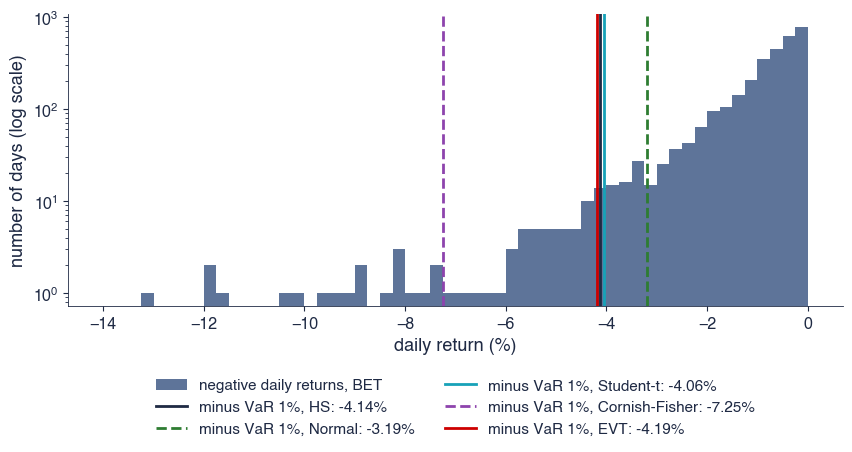

In [14]:
# Solution
def b1_methods(k='bet', save=True):
    """B1: five methods for the BET; chart of the left tail with the five values of minus VaR 1%."""
    d = five_methods(k)
    x = returns(k)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.hist(x[x < 0], bins=np.arange(-14, 0.01, 0.25), color=st.MainBlue, alpha=0.7, label=f'negative daily returns, {NAME[k]}')
    cols = {'HS': st.DarkText, 'Normal': st.Forest, 'Student-t': st.Teal, 'Cornish-Fisher': st.Purple, 'EVT': st.IDAred}
    for m, c in cols.items():
        ax.axvline(-d[m][0], color=c, lw=2, ls='--' if m in ('Normal', 'Cornish-Fisher') else '-',
                   label=f'minus VaR 1%, {m}: {-d[m][0]:.2f}%')
    ax.set_yscale('log')
    ax.set_xlabel('daily return (%)')
    ax.set_ylabel('number of days (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig(f'ch10_sem_b1' if k == 'bet' else f'ch10_sem_b1_{k}')
    return d


b1 = b1_methods('bet', save=False)
pd.DataFrame({m: {'VaR 1%': b1[m][0], 'ES 2.5%': b1[m][1]} for m in ['HS', 'Normal', 'Student-t', 'Cornish-Fisher', 'EVT']}).round(2)

**Interpretation of the result.** Historical simulation and EVT agree; the Normal VaR 1% is about a quarter too low, and Cornish–Fisher is outside its range with an excess kurtosis above 10.

## B2 [Proposed]: TLV, SNP and Bitcoin

**Question.** Does the ranking of the methods found for the BET hold for two BVB stocks and for Bitcoin? Model: B1.

1. Compute VaR 1% and ES 2.5% of each series by the five methods of B1.
2. Compute by how much the Normal VaR 1% is below the historical VaR 1%.
3. Report $\hat\nu$, $\hat\xi$ and the excess kurtosis of each series.
4. Interpretation: for which series does the Normal understate VaR 1% most?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: backtesting the S&P 500 year by year

**Question.** Which of two VaR 1% models would a supervisor have penalised, year by year, since 2015?

1. Compute the one-day VaR 1% by historical simulation on the last 250 days.
2. Compute the one-day GARCH(1,1)-t VaR 1%, re-estimating the model at the start of every year on all earlier data.
3. Count the exceptions of each model in every calendar year and give the Basel zone of each year.
4. Run the Kupiec and Christoffersen tests on the whole period.
5. Interpretation: which model would a supervisor have penalised in 2022?

**Report:** the chart, six statistics with p-values and two sentences.

        n  HS GARCH-t zone_HS  zone_G
2015  252   5       4  yellow   green
2016  252   1       2   green   green
2017  250   2       3   green   green
2018  251   5       7  yellow  yellow
2019  252   0       4   green   green
2020  253   8       7  yellow  yellow
2021  252   1       8   green  yellow
2022  251  10       2     red   green
2023  250   0       1   green   green
2024  252   6       4  yellow   green
2025  250   4       5   green  yellow
2026  179   1       2   green   green


{'HS': {'n': 2944,
  'x': 43,
  'rate': 0.014605978260869566,
  'lr_uc': 5.523926689484767,
  'p_uc': 0.01875810748781139,
  'lr_ind': 23.040788967735317,
  'p_ind': 1.5860053260223928e-06,
  'lr_cc': 28.564715657220084,
  'p_cc': 6.269758407155213e-07,
  'n11': 7,
  'red': 1,
  'yellow': 4},
 'GARCH-t': {'n': 2944,
  'x': 49,
  'rate': 0.016644021739130436,
  'lr_uc': 10.939232824991734,
  'p_uc': 0.000941491452707982,
  'lr_ind': 6.784367041251535,
  'p_ind': 0.009195963205972638,
  'lr_cc': 17.72359986624327,
  'p_cc': 0.0001416997843534529,
  'n11': 4,
  'red': 0,
  'yellow': 4}}

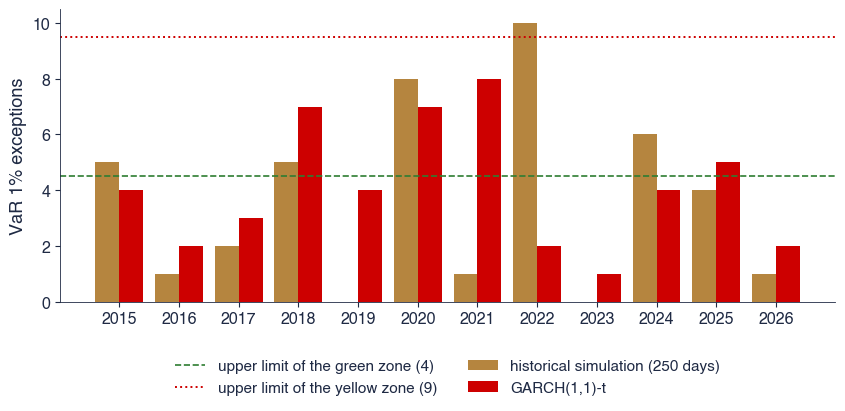

In [16]:
# Solution
def b3_backtest(k='sp500', save=True):
    """B3: yearly backtest of the S&P 500; bar chart of the exceptions per calendar year with the zone limits."""
    d = yearly_backtest(k)
    ys = list(d['years'])
    fig, ax = plt.subplots(figsize=(10, 3.8))
    xx = np.arange(len(ys))
    ax.bar(xx - 0.2, [d['years'][y]['HS'] for y in ys], 0.4, color=st.Amber, label='historical simulation (250 days)')
    ax.bar(xx + 0.2, [d['years'][y]['GARCH-t'] for y in ys], 0.4, color=st.IDAred, label='GARCH(1,1)-t')
    ax.axhline(4.5, color=st.Forest, ls='--', lw=1.2, label='upper limit of the green zone (4)')
    ax.axhline(9.5, color=st.IDAred, ls=':', lw=1.4, label='upper limit of the yellow zone (9)')
    ax.set_xticks(xx)
    ax.set_xticklabels(ys)
    ax.set_ylabel('VaR 1% exceptions')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch10_sem_b3' if k == 'sp500' else f'ch10_sem_b3_{k}')
    return d


b3 = b3_backtest('sp500', save=False)
print(pd.DataFrame(b3['years']).T)
{m: b3[m] for m in ['HS', 'GARCH-t']}

**Interpretation of the result.** In 2022 historical simulation had 10 exceptions (red zone) while GARCH-t had 2: the slow window is penalised when volatility rises; GARCH-t paid in calmer years such as 2021.

## B4 [Proposed]: backtesting the BET and Bitcoin

**Question.** Does the conclusion of B3 hold on the BVB and for Bitcoin? Model: B3.

1. Compute both VaR 1% forecasts as in B3 (BET from 2015, Bitcoin from 2016).
2. Count the exceptions per calendar year and give the zones.
3. Run the Kupiec and Christoffersen tests on the whole period.
4. Interpretation: which model would you keep for each series?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: a portfolio of two BVB stocks

**Question.** How much does diversification between Banca Transilvania and OMV Petrom reduce VaR 1%, and does it survive a crisis?

1. Compute the variance–covariance VaR 1% of the portfolio, the two individual VaRs and the diversification benefit.
2. Compute the historical VaR 1% and ES 2.5% of the portfolio.
3. Compute the correlation in 2017 and in February–May 2020, and the tail dependence at $q = 5\%$ and $q = 1\%$.
4. Fit a t copula and compute the copula VaR 1% with empirical margins.
5. Interpretation: why does the variance–covariance VaR understate the risk of this portfolio?

**Report:** eight numbers, the chart and two sentences.

{'n': 3461,
 'first': '2010-01-04',
 'mu': [0.10765084550370292, 0.09794485003393967],
 'sd': [1.8383006619761955, 1.6988255846933737],
 'corr': 0.4584471559818765,
 'sp': 1.5106931188137749,
 'mp': 0.1027978477688213,
 'var_n': 3.411599877511731,
 'es_n': 3.4289047435534825,
 'var_single': [4.16887599133249, 3.8541144372836786],
 'var_hs': 4.121103114338709,
 'es_hs': 4.508066956470107,
 'var_hs_single': [5.103550295857984, 4.42188011791681],
 'corr_2017': 0.32165671630911596,
 'corr_2020': 0.6862608198262599,
 'tail': {'0.05': 0.3640566310314937, '0.01': 0.4045073678127709},
 'copula': {'tau': 0.27254511897802264,
  'rho': 0.4151547262360154,
  'nu': 5.0,
  'll_t': 394.2116349649539,
  'll_g': 338.8907394209313,
  'lambda_t': 0.16639593864875477,
  'pearson': 0.4584471559818765,
  'spearman': 0.3904837775584412},
 'var_sum': 4.011495214308084,
 'var_hs_sum': 4.762715206887397,
 'benefit': 0.14954407390457902,
 'var_gauss': 3.844508657374382,
 'es_gauss': 4.067762798560285,
 'var_t': 

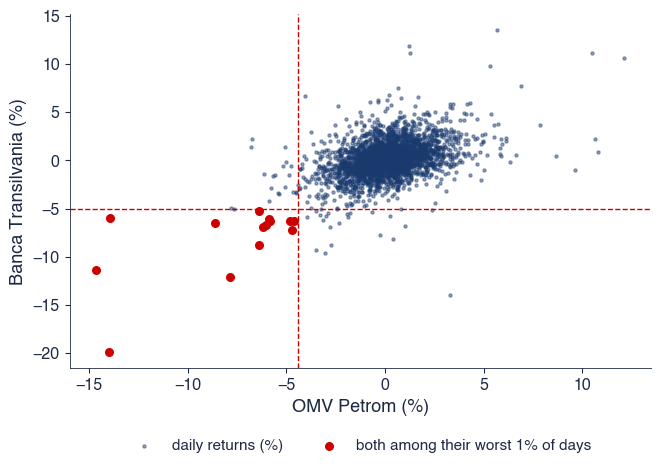

In [18]:
# Solution
def b5_portfolio(keys=('tlv', 'snp'), save=True):
    """B5: Banca Transilvania and OMV Petrom, 50/50; scatter of the daily returns with the worst 1% days."""
    d = two_asset_portfolio(keys)
    R = d.pop('R')
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    q = R.quantile(0.01)
    both = (R.iloc[:, 0] <= q.iloc[0]) & (R.iloc[:, 1] <= q.iloc[1])
    ax.scatter(R.iloc[:, 1], R.iloc[:, 0], s=5, color=st.MainBlue, alpha=0.45, label='daily returns (%)')
    ax.scatter(R.iloc[:, 1][both], R.iloc[:, 0][both], s=30, color=st.IDAred, label='both among their worst 1% of days')
    ax.axhline(q.iloc[0], color=st.IDAred, ls='--', lw=1)
    ax.axvline(q.iloc[1], color=st.IDAred, ls='--', lw=1)
    ax.set_xlabel(f'{NAME[keys[1]]} (%)')
    ax.set_ylabel(f'{NAME[keys[0]]} (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch10_sem_b5')
    d['n_both'] = int(both.sum())
    d['exp_ind'] = float(len(R) * 0.0001)
    return d


b5 = b5_portfolio(('tlv', 'snp'), save=False)
b5

**Interpretation of the result.** Both margins have heavy tails and the two stocks fall together on the worst days, when the correlation is highest: the Normal variance–covariance VaR is well below the historical one.

## B6 [Proposed]: DAX and S&P 500

**Question.** Is the Gaussian copula good enough for a 50/50 DAX and S&P 500 portfolio? Model: B5.

1. Compute the variance–covariance and the historical VaR 1% and ES 2.5%.
2. Fit the Gaussian and the t copula and compare them with the LR statistic.
3. Compute the copula VaR 1% and ES 2.5% with empirical margins for both copulas.
4. Interpretation: is the Gaussian copula good enough for this pair?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: is ES 2.5% as large as VaR 1%?

**Question.** Basel replaced VaR 1% by ES 2.5% because the two are equal for Normal returns; how close are they on real data and in crises? Models: B1, A5.

1. Compute the ratio ES 2.5% / VaR 1% by historical simulation on the whole sample of each series.
2. Compute the same ratio on the 500 days that end in March 2009 and in May 2020.
3. Compute the ratio implied by a fitted Student-t distribution.
4. Interpretation: is ES 2.5% a stricter rule than VaR 1% on these markets?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant summarised the risk of the BET over the last 500 days. It answered:

- (a) the VaR 99% of the BET is a negative number, the 1% quantile;
- (b) ES is always at least as large as VaR, so ES 2.5% is above VaR 1%;
- (c) the 10-day VaR 1% is 10 times the one-day VaR 1%;
- (d) with 8 exceptions in 250 days the model stays in the green zone;
- (e) VaR is subadditive, so the VaR of a portfolio never exceeds the sum of the VaRs of its parts;
- (f) if the exceptions cluster, the Christoffersen test can reject even when their number is right.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
